## Mean Reversion Tests

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.random  import randn

from statsmodels.tsa.stattools import adfuller
from scipy import stats

In [18]:
spy = yf.download("SPY", period="2y", auto_adjust=True)["Close"]
prices = spy.dropna().values

[*********************100%***********************]  1 of 1 completed


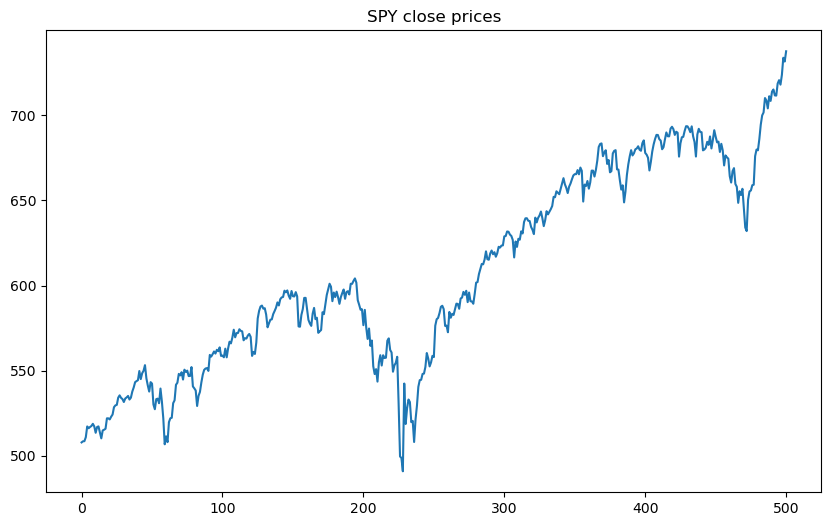

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(prices)
plt.title("SPY close prices")
plt.show()

## ADF Tests for stationarity

In [20]:
adf = adfuller(prices)
adf

(np.float64(-0.3080688327926257),
 np.float64(0.9243537442624772),
 4,
 496,
 {'1%': np.float64(-3.4436029548776395),
  '5%': np.float64(-2.867384756137026),
  '10%': np.float64(-2.5698830308597813)},
 np.float64(3104.2359566045366))

---
- first entry (ADF-statistic) ~ -0.308
- second entry (p-value) ~ 0.924
- number of lags used
- numbrt of observations
- critical values

Since the calculated value of the test statistic is larger than any of the critical values at the 1, 5 or 10 percent levels, we cannot reject the null hypothesis of 
and thus we are unlikely to have found a mean reverting time series.

The key to interpreting these results is the p-value.  A high p-value (0.924, or 92.4%) means you fail to reject the null hypothesis.  The null hypothesis for an ADF test is that the series has a unit root and is non-stationary (i.e., not mean-reverting).
 
 ---

## Hurst Exponent

In [21]:
def hurst_exponent(series, max_lag=100):
    lags = range(2, max_lag)
    log_series = np.log(series)

    variances = [np.var(log_series[tau:] - log_series[:-tau]) for tau in lags]
    log_vars = np.log(variances)
    log_lags = np.log(lags)

    slope, intercept, r_value, p_value, std_err = stats.linregress(log_lags, log_vars)
    H = slope / 2
    return H, intercept, list(zip(log_lags, log_vars))

In [22]:
H, c, plot_data = hurst_exponent(prices)

print(f"Hurst Exponent H = {H:.6f}")
print()
if H < 0.5:
    print("H < 0.5 → Mean-reverting series")
elif H > 0.5:
    print("H > 0.5 → Trending series")
else:
    print("H ≈ 0.5 → Random walk (GBM)")

Hurst Exponent H = 0.401754

H < 0.5 → Mean-reverting series


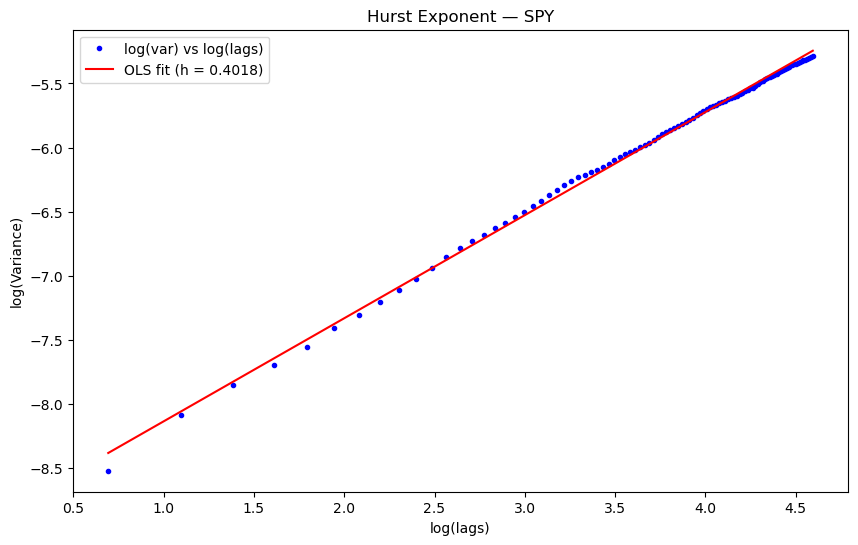

In [62]:
log_lags, log_vars = zip(*plot_data)
plt.figure(figsize=(10, 6))
plt.plot(log_lags, log_vars, "b.", label="log(var) vs log(lags)")
fit_line = [H * 2 * lt + c for lt in log_lags]
plt.plot(log_lags, fit_line, "r-", label=f"OLS fit (h = {H:.4f})")
plt.legend(loc=0)
plt.xlabel("log(lags)")
plt.ylabel("log(Variance)")
plt.title("Hurst Exponent — SPY")
plt.show()

## Variance ratio test

In [24]:
log_prices = np.log(prices)
def variance_ratio_test(log_series, max_lag=100):
    n = len(log_series)

    one_day_returns = log_series[1:] - log_series[:-1]
    var_1 = np.var(one_day_returns, ddof=1)

    results = []
    for tau in range(2, max_lag + 1):
        tau_returns = log_series[tau:] - log_series[:-tau]
        var_tau = np.var(tau_returns, ddof=1)

        vr = var_tau / (tau * var_1)
        # z-statistic (Lo & MacKinlay 1988 formula)
        # Tests H0: vr = 1 (random walk)
        m = tau * (n - tau) * (1 - tau / n)
        z = (vr - 1)/ np.sqrt(2 * (2 * tau - 1) * (tau - 1)/ (3 * tau * n))

        p_value = 2 * (1 - stats.norm.cdf(abs(z)))   # two-tailed
        
        results.append({
            'tau': tau,
            'VR': vr,
            'z': z,
            'p_value': p_value
        })

    return pd.DataFrame(results)  

In [25]:
vr_df = variance_ratio_test(log_prices, max_lag=100)
print(f"{'Lag':<10} {'VR':<10} {'z-stat':<10} {'p-value':<10} {'Significant?'}")
print("-" * 55)
for _, row in vr_df.iterrows():
    sig = "YES *" if row['p_value'] < 0.05 else ""
    print(f"{int(row['tau']):<10} {row['VR']:.4f}    {row['z']:.4f}    {row['p_value']:.4f}    {sig}")

Lag        VR         z-stat     p-value    Significant?
-------------------------------------------------------
2          0.9148    -1.9065    0.0566    
3          0.9413    -0.8821    0.3777    
4          0.8929    -1.2816    0.2000    
5          0.8323    -1.7130    0.0867    
6          0.8017    -1.7952    0.0726    
7          0.7930    -1.6996    0.0892    
8          0.7722    -1.7235    0.0848    
9          0.7596    -1.6952    0.0900    
10         0.7461    -1.6834    0.0923    
11         0.7428    -1.6138    0.1066    
12         0.7425    -1.5376    0.1241    
13         0.7442    -1.4599    0.1443    
14         0.7416    -1.4148    0.1571    
15         0.7293    -1.4265    0.1537    
16         0.7209    -1.4194    0.1558    
17         0.7112    -1.4204    0.1555    
18         0.7015    -1.4233    0.1547    
19         0.6967    -1.4042    0.1603    
20         0.6858    -1.4153    0.1570    
21         0.6836    -1.3882    0.1651    
22         0.6826    -1.358

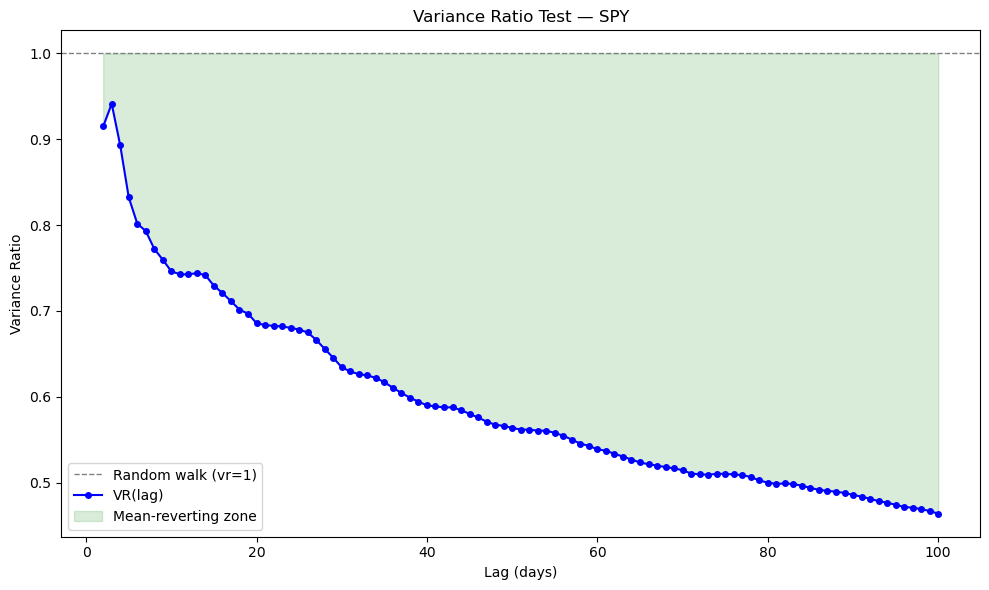

In [61]:
# Plots across lags

plt.figure(figsize=(10, 6))
plt.axhline(y=1, color="gray", linestyle="--", lw=1, label="Random walk (vr=1)")
plt.plot(vr_df["tau"], vr_df["VR"], "b-o", markersize=4, label="VR(lag)")
plt.fill_between(vr_df["tau"], vr_df["VR"], 1, where=(vr_df["VR"] < 1), alpha=0.15, color="green", label="Mean-reverting zone")
plt.xlabel("Lag (days)")
plt.ylabel("Variance Ratio")
plt.title("Variance Ratio Test — SPY")
plt.legend()
plt.tight_layout()
plt.show()